In [1]:
from resources.imports import *

import torch
import torch.nn as nn

from resources.MLdata import DATA
from resources.MLfunc import CustomQuantileLoss, EarlyStopping, weights_init
from resources.MLmodels import MODEL, MLP, GNN

# Stress-Strain Curve

In [6]:
DAT = DATA(
    path=1, 
    path_add="",
    load=True, 
    LAT="FCC", 
    dis="disNodes", 
    dN=0.2, 
    mechMode="both",
    multi=True,
    nsims=1000,
    model="GNN",
    scale=False, #("maxmin", "inout"),
    reduce_dim=False #("PCA", "out", 0.95, 10)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

c:\Users\exy053\OneDrive - Queen Mary, University of London\Documents\Research\p1-LatticeFractureToughness\p1git-Lattices\code\resources\lattices.py:637: RuntimeWarning: divide by zero encountered in double_scalars
  return np.array([np.cos(np.arctan([n0[1]/n0[0]]))[0], np.sin(np.arctan([n0[1]/n0[0]]))[0]])


Using device: cpu


In [7]:
if DAT.UTmechTest:
    print("UT shape:", DAT.UT_all_in.shape, DAT.UT_all_out.shape)
if DAT.FTmechTest:
    print("FT shape:", DAT.FT_all_in.shape, DAT.FT_all_out.shape)

UT shape: (1000, 722, 2) (1000, 201)
FT shape: (1000, 710, 2) (1000, 201)


In [8]:
if DAT.UTmechTest:
    print("ALL   - in (min, max), out (min, max):", DAT.UT_all_in.min(), DAT.UT_all_in.max(), DAT.UT_all_out.min(), DAT.UT_all_out.max())
    print("Train - in (min, max), out (min, max):", DAT.UT_train_in.min(), DAT.UT_train_in.max(), DAT.UT_train_out.min(), DAT.UT_train_out.max())
    print("Val   - in (min, max), out (min, max):", DAT.UT_val_in.min(), DAT.UT_val_in.max(), DAT.UT_val_out.min(), DAT.UT_val_out.max())
    print("Test  - in (min, max), out (min, max):", DAT.UT_test_in.min(), DAT.UT_test_in.max(), DAT.UT_test_out.min(), DAT.UT_test_out.max(), "\n")
if DAT.FTmechTest:
    print("ALL   - in (min, max), out (min, max):", DAT.FT_all_in.min(), DAT.FT_all_in.max(), DAT.FT_all_out.min(), DAT.FT_all_out.max())
    print("Train - in (min, max), out (min, max):", DAT.FT_train_in.min(), DAT.FT_train_in.max(), DAT.FT_train_out.min(), DAT.FT_train_out.max())
    print("Val   - in (min, max), out (min, max):", DAT.FT_val_in.min(), DAT.FT_val_in.max(), DAT.FT_val_out.min(), DAT.FT_val_out.max())
    print("Test  - in (min, max), out (min, max):", DAT.FT_test_in.min(), DAT.FT_test_in.max(), DAT.FT_test_out.min(), DAT.FT_test_out.max(), "\n")

ALL   - in (min, max), out (min, max): -1.414215100000007 1.4142150999999998 -29.222364320678714 47.50582990936279
Train - in (min, max), out (min, max): -1.414211299999998 1.4142113000000016 -28.481291174087527 48.45298005096436
Val   - in (min, max), out (min, max): -1.4142150000000129 1.4142150000000129 -28.308619424057014 45.86591520233155
Test  - in (min, max), out (min, max): -1.414211299999998 1.4142150999999998 -27.956339748687743 45.84270200794221 

ALL   - in (min, max), out (min, max): -1.414215100000007 1.4142150999999998 -72300.2187109375 36724.375
Train - in (min, max), out (min, max): -1.414211299999998 1.4142113000000016 -65958.0126171875 32675.0546875
Val   - in (min, max), out (min, max): -1.4142150000000129 1.4142150000000129 -72300.2187109375 34365.6796875
Test  - in (min, max), out (min, max): -1.414211299999998 1.4142150999999998 -70764.41921874999 45877.7109375 



## Multi-Layer Perceptrion (MLP)

In [ ]:
# MLP1 = MODEL(
#     typ="MLP",
#     model=MLP(in_size=DAT.UT_train_in.shape[-1], 
#               h_size=[4096, 2048, 512],#1024, 1024, 1024, 512, 512], 
#               out_size=DAT.UT_train_out.shape[-1], 
#               act="relu",
#               block="mlp",
#               norm="layer", 
#               dropout=0.2).to(device), 
#     lossf = CustomQuantileLoss(quantiles=[0.5, 0.45, 0.1], zone_boundaries=(50, 150), err_type="L2"),
#     opt=("adam", 0), #("adam", 1e-4),
#     batch=16,
#     lr=9e-4,
#     data=DAT,
#     mechMode=DAT.mechMode,
#     scheduler=("min", 0.2427, 18, 1e-4), 
#     earlyStop=EarlyStopping(patience=50, min_delta=1e-4, verbose=True),
#     w_init=weights_init,
#     device=device
# )

# MLP1._summary()

In [6]:
# MLP1.train(n_epochs=1000, verbose=20, plot=True)

In [7]:
# MLP1.predict(test_dataloader=None, plot=True)

## Graph Neural Network (GNN)

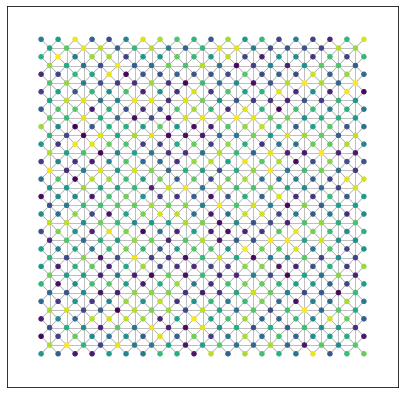

Layer (type:depth-idx)                   Output Shape              Param #
GNN                                      [16, 201]                 --
├─GCNConv: 1-1                           [11552, 10]               10
│    └─Linear: 2-1                       [11552, 10]               20
│    └─SumAggregation: 2-2               [11552, 10]               --
├─LayerNorm: 1-2                         [11552, 10]               20
├─ReLU: 1-3                              [11552, 10]               --
├─Dropout: 1-4                           [11552, 10]               --
├─ModuleList: 1-7                        --                        (recursive)
│    └─gcnBlock: 2-3                     [11552, 100]              --
│    │    └─GCNConv: 3-1                 [11552, 100]              1,100
│    │    └─LayerNorm: 3-2               [11552, 100]              200
│    │    └─ReLU: 3-3                    [11552, 100]              --
├─Dropout: 1-6                           [11552, 100]              --
├─

In [9]:
GNN1 = MODEL(
    typ=DAT.model,
    model=GNN(in_size=DAT.FT_train_in.shape[-1], 
              h_size=[10, 100, 201],
              out_size=DAT.FT_train_out.shape[-1], 
              act="relu",
              block="gcn",
              norm="layer", 
              dropout=0.2).to(device), 
    lossf = CustomQuantileLoss(quantiles=[0.5, 0.45, 0.1], zone_boundaries=(50, 150), err_type="L2"),
    opt=("adam", 0), #("adam", 1e-4),
    batch=16,
    lr=9e-4,
    data=DAT,
    mechMode=DAT.mechMode,
    scheduler=("min", 0.2427, 18, 1e-4), 
    earlyStop=EarlyStopping(patience=50, min_delta=1e-4, verbose=True),
    w_init=weights_init,
    device=device
)

GNN1._summary()

 -> Epoch 1/1000 || LOSS - train: 22.721457, val: 15.447402 | MSE - train: 48.508801, val: 33.381617 | RMSE - train: 6.964826, val: 5.777683 | LR: 9.00e-04
 -> Epoch 20/1000 || LOSS - train: 9.905612, val: 9.707489 | MSE - train: 21.084250, val: 20.852539 | RMSE - train: 4.591759, val: 4.566458 | LR: 9.00e-04
 -> Epoch 40/1000 || LOSS - train: 9.897469, val: 9.703311 | MSE - train: 21.156378, val: 20.892237 | RMSE - train: 4.599606, val: 4.570803 | LR: 9.00e-04
 -> Epoch 60/1000 || LOSS - train: 9.902253, val: 9.678529 | MSE - train: 21.133937, val: 20.745276 | RMSE - train: 4.597166, val: 4.554698 | LR: 2.18e-04
 !!! Early stopping triggered after 50 epochs without improvement !!!
================ Training Complete ================
 Best Epoch: 26, with LOSS: 9.665358, MSE: 20.676265 and RMSE: 4.547116 ==================


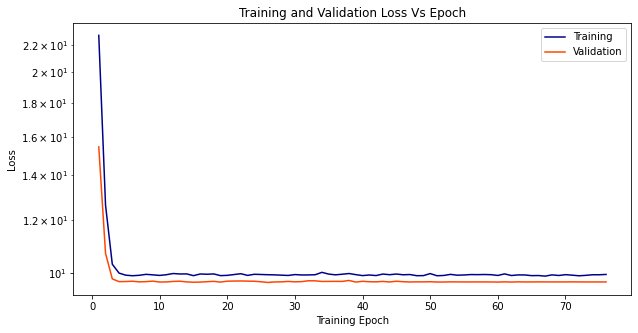

 -> Epoch 1/1000 || LOSS - train: 206111790.222222, val: 199493932.800000 | MSE - train: 297072234.496000, val: 291114835.273563 | RMSE - train: 17235.783547, val: 17062.087659 | LR: 9.00e-04
 -> Epoch 20/1000 || LOSS - train: 195931619.555556, val: 189622285.381818 | MSE - train: 282959989.376000, val: 276632811.328736 | RMSE - train: 16821.414607, val: 16632.282204 | LR: 9.00e-04
 -> Epoch 40/1000 || LOSS - train: 173902516.698413, val: 167865188.945455 | MSE - train: 251219383.040000, val: 244997000.790805 | RMSE - train: 15849.901673, val: 15652.380036 | LR: 9.00e-04
 -> Epoch 60/1000 || LOSS - train: 146941834.920635, val: 141201622.545455 | MSE - train: 212545625.728000, val: 206817040.000000 | RMSE - train: 14578.944603, val: 14381.134865 | LR: 9.00e-04
 -> Epoch 80/1000 || LOSS - train: 118969539.301587, val: 114009925.963636 | MSE - train: 173726227.456000, val: 168725900.266667 | RMSE - train: 13180.524552, val: 12989.453424 | LR: 9.00e-04
 -> Epoch 100/1000 || LOSS - train: 

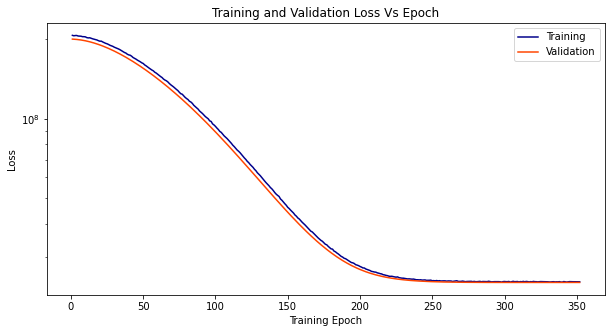

In [10]:
GNN1.train(n_epochs=1000, verbose=20, plot=True)

Best prediction: 964, Worst prediction: 22


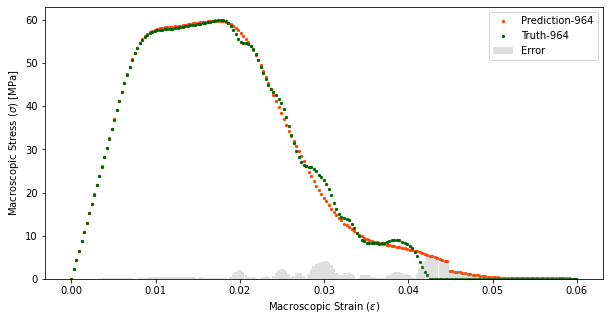

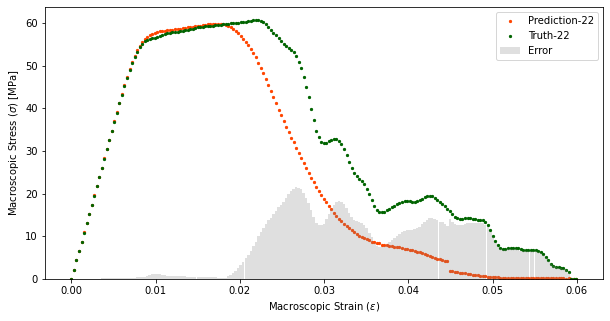

Best prediction: 980, Worst prediction: 375


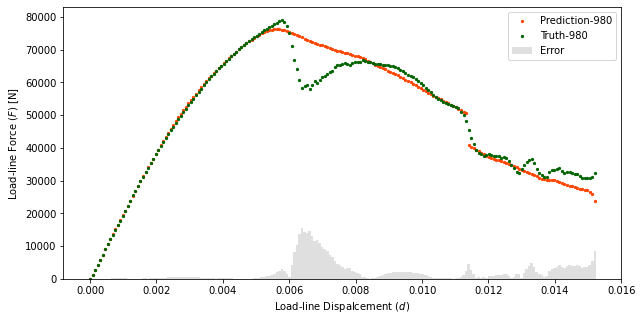

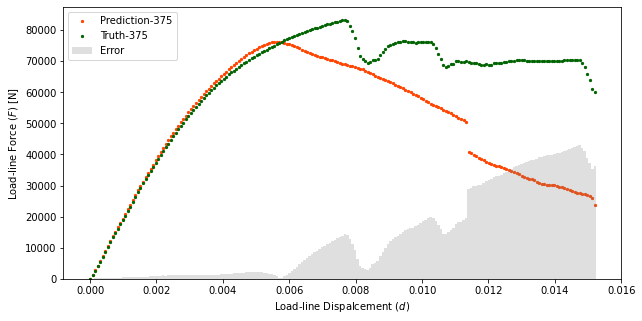

In [11]:
GNN1.predict(test_dataloader=None, plot=True)